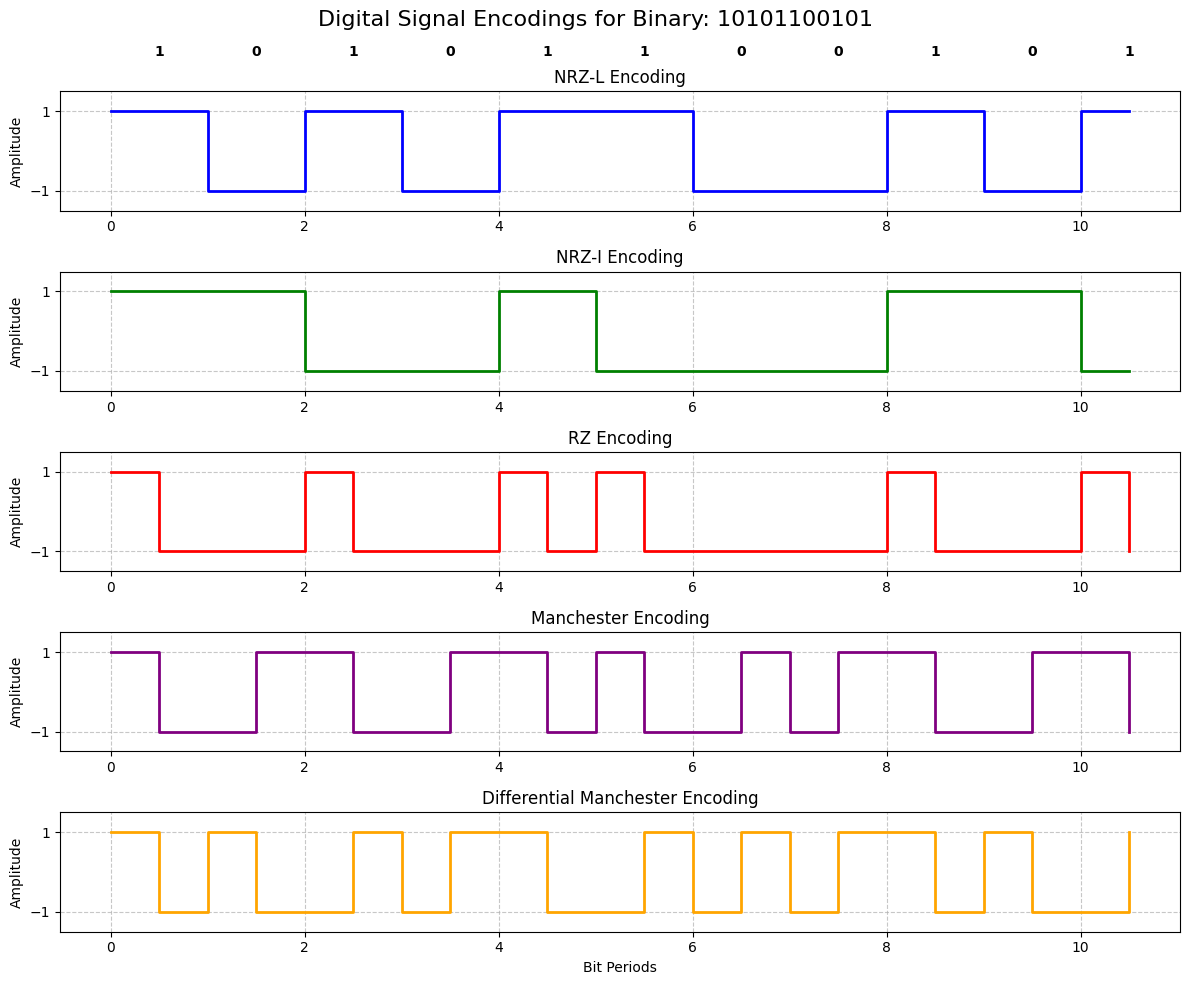

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Binary string to encode
binary_string = "10101100101"

# Create time axis (each bit has 2 samples for better visualization)
t = np.linspace(0, len(binary_string), len(binary_string)*2, endpoint=False)

# Initialize signal arrays
nrz_l = []
nrz_i = []
rz = []
manchester = []
diff_manchester = []

# i. NRZ-L Encoding
for bit in binary_string:
    level = 1 if bit == '1' else -1
    nrz_l.extend([level, level])  # Maintain level for the entire bit duration

# ii. NRZ-I Encoding
current_level = -1  # Start with low level
for bit in binary_string:
    if bit == '1':
        current_level *= -1  # Invert level on '1'
    nrz_i.extend([current_level, current_level])  # Maintain level for entire bit

# iii. RZ Encoding
for bit in binary_string:
    if bit == '1':
        rz.extend([1, -1])  # High then low within the bit period
    else:
        rz.extend([-1, -1])  # Low for entire bit period

# iv. Manchester Encoding (IEEE 802.3)
for bit in binary_string:
    if bit == '1':
        manchester.extend([1, -1])  # High-to-low transition
    else:
        manchester.extend([-1, 1])  # Low-to-high transition

# v. Differential Manchester Encoding
current_level = 1  # Start with high level (arbitrary)
for bit in binary_string:
    if bit == '0':
        current_level *= -1  # Transition at start of bit for '0'
    # Mid-bit transition always occurs
    diff_manchester.extend([current_level, -current_level])
    current_level = -current_level  # Update level after mid-bit transition

# Create the plot
fig, axs = plt.subplots(5, 1, figsize=(12, 10))
fig.suptitle('Digital Signal Encodings for Binary: 10101100101', fontsize=16)

# Plot NRZ-L
axs[0].step(t, nrz_l, where='post', linewidth=2, color='blue')
axs[0].set_ylim(-1.5, 1.5)
axs[0].set_yticks([-1, 1])
axs[0].set_ylabel('Amplitude')
axs[0].set_title('NRZ-L Encoding')
axs[0].grid(True, linestyle='--', alpha=0.7)

# Plot NRZ-I
axs[1].step(t, nrz_i, where='post', linewidth=2, color='green')
axs[1].set_ylim(-1.5, 1.5)
axs[1].set_yticks([-1, 1])
axs[1].set_ylabel('Amplitude')
axs[1].set_title('NRZ-I Encoding')
axs[1].grid(True, linestyle='--', alpha=0.7)

# Plot RZ
axs[2].step(t, rz, where='post', linewidth=2, color='red')
axs[2].set_ylim(-1.5, 1.5)
axs[2].set_yticks([-1, 1])
axs[2].set_ylabel('Amplitude')
axs[2].set_title('RZ Encoding')
axs[2].grid(True, linestyle='--', alpha=0.7)

# Plot Manchester
axs[3].step(t, manchester, where='post', linewidth=2, color='purple')
axs[3].set_ylim(-1.5, 1.5)
axs[3].set_yticks([-1, 1])
axs[3].set_ylabel('Amplitude')
axs[3].set_title('Manchester Encoding')
axs[3].grid(True, linestyle='--', alpha=0.7)

# Plot Differential Manchester
axs[4].step(t, diff_manchester, where='post', linewidth=2, color='orange')
axs[4].set_ylim(-1.5, 1.5)
axs[4].set_yticks([-1, 1])
axs[4].set_ylabel('Amplitude')
axs[4].set_title('Differential Manchester Encoding')
axs[4].grid(True, linestyle='--', alpha=0.7)
axs[4].set_xlabel('Bit Periods')

# Add binary labels at the top
for i, bit in enumerate(binary_string):
    axs[0].text(i + 0.5, 2.5, bit, ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()